# ASSIGNMENT 1: Understanding Generative and Discriminative Models Using MNIST

## Objective
To understand the difference between a **discriminative model** and a **generative model** using handwritten digits **0 and 1** from the MNIST dataset.

- **Discriminative model:** Logistic Regression for classifying digits 0 and 1.
- **Generative model:** Autoencoder for learning digit patterns and producing reconstructed/generated-like digit examples.


## 1. Import Libraries

In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


## 2. Load and Prepare the MNIST Dataset

In [3]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Keep only images representing digits 0 and 1
train_filter = (y_train == 0) | (y_train == 1)
test_filter = (y_test == 0) | (y_test == 1)

x_train = x_train[train_filter]
y_train = y_train[train_filter]
x_test = x_test[test_filter]
y_test = y_test[test_filter]

# Normalize pixel values to the range 0 to 1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)
print("Training labels:", np.unique(y_train))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images: (12665, 28, 28)
Testing images: (2115, 28, 28)
Training labels: [0 1]


## 3. Display Sample Images

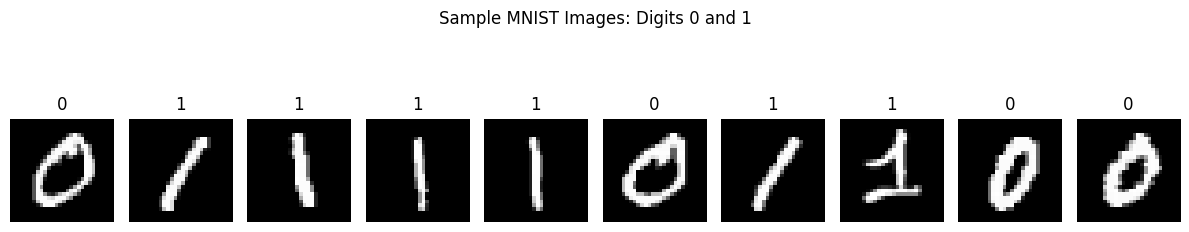

In [4]:
plt.figure(figsize=(12, 3))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.suptitle("Sample MNIST Images: Digits 0 and 1")
plt.tight_layout()
plt.show()


## 4. Discriminative Model: Logistic Regression

In [5]:
# Flatten each 28 x 28 image into a vector of 784 values
x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

# Create and train the discriminative model
classifier = LogisticRegression(max_iter=1000)
classifier.fit(x_train_flat, y_train)

# Predict test labels
predictions = classifier.predict(x_test_flat)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Discriminative Model Accuracy: {accuracy * 100:.2f}%")


Discriminative Model Accuracy: 99.95%


## 5. Visual Comparison of Real Images and Predictions

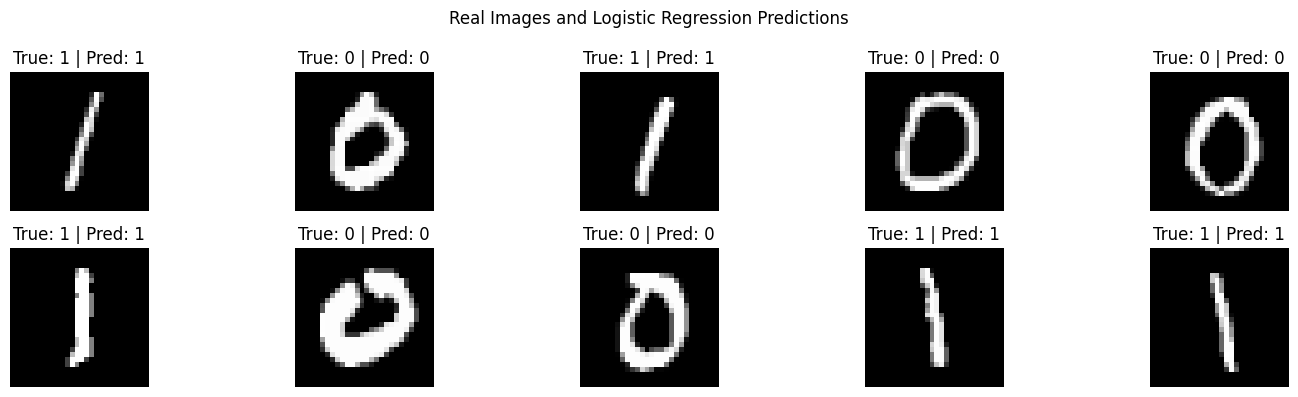

In [6]:
plt.figure(figsize=(15, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"True: {y_test[i]} | Pred: {predictions[i]}")
    plt.axis("off")

plt.suptitle("Real Images and Logistic Regression Predictions")
plt.tight_layout()
plt.show()


## 6. Generative Model: Autoencoder

The autoencoder learns the important patterns in the digit images by:
1. Compressing the image into a smaller latent representation.
2. Reconstructing the image from that representation.

This helps the model learn the underlying visual patterns of digits 0 and 1.


In [7]:
# Autoencoder architecture
input_img = Input(shape=(784,))

# Encoder: compress the image
encoded = Dense(64, activation="relu")(input_img)
latent = Dense(16, activation="relu", name="latent_space")(encoded)

# Decoder: reconstruct the image
decoded_hidden = Dense(64, activation="relu")(latent)
decoded = Dense(784, activation="sigmoid")(decoded_hidden)

# Create autoencoder
autoencoder = Model(input_img, decoded)

# Create separate encoder model
encoder = Model(input_img, latent)

# Create decoder model for generating/reconstructing images from latent vectors
latent_input = Input(shape=(16,))
decoder_layer_1 = autoencoder.layers[-2]
decoder_layer_2 = autoencoder.layers[-1]
decoder = Model(latent_input, decoder_layer_2(decoder_layer_1(latent_input)))

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,328 (403.62 KB)

 Trainable params: 103,328 (403.62 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Autoencoder

In [8]:
history = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=10,
    batch_size=256,
    validation_data=(x_test_flat, x_test_flat),
    verbose=1
)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.4106 - val_loss: 0.2227
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1891 - val_loss: 0.1665
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1517 - val_loss: 0.1370
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1337 - val_loss: 0.1272
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1245 - val_loss: 0.1185
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1173 - val_loss: 0.1131
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1127 - val_loss: 0.1087
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1085 - val_loss: 0.1046
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1049 - val_loss: 0.1015
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1018 - val_loss: 0.0988


## 8. Plot Autoencoder Training Loss

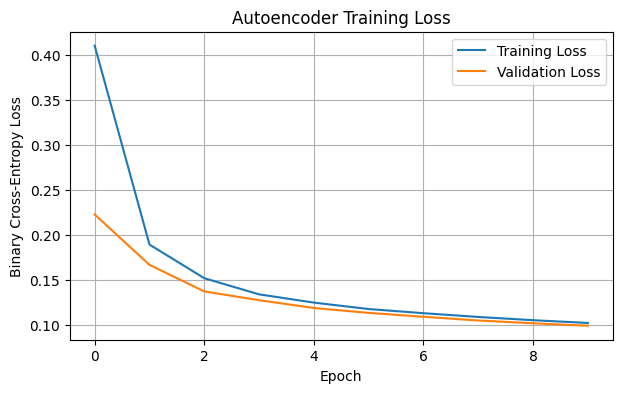

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.grid()
plt.show()


## 9. Generate/Reconstruct Digit Images

In [10]:
# Pass test images through the autoencoder
generated = autoencoder.predict(x_test_flat[:10], verbose=0)

# Reshape back to 28 x 28 images
generated = generated.reshape(-1, 28, 28)

print("Generated/Reconstructed digit images:", generated.shape)


Generated/Reconstructed digit images: (10, 28, 28)


## 10. Visual Comparison: Real Images vs Generated Images

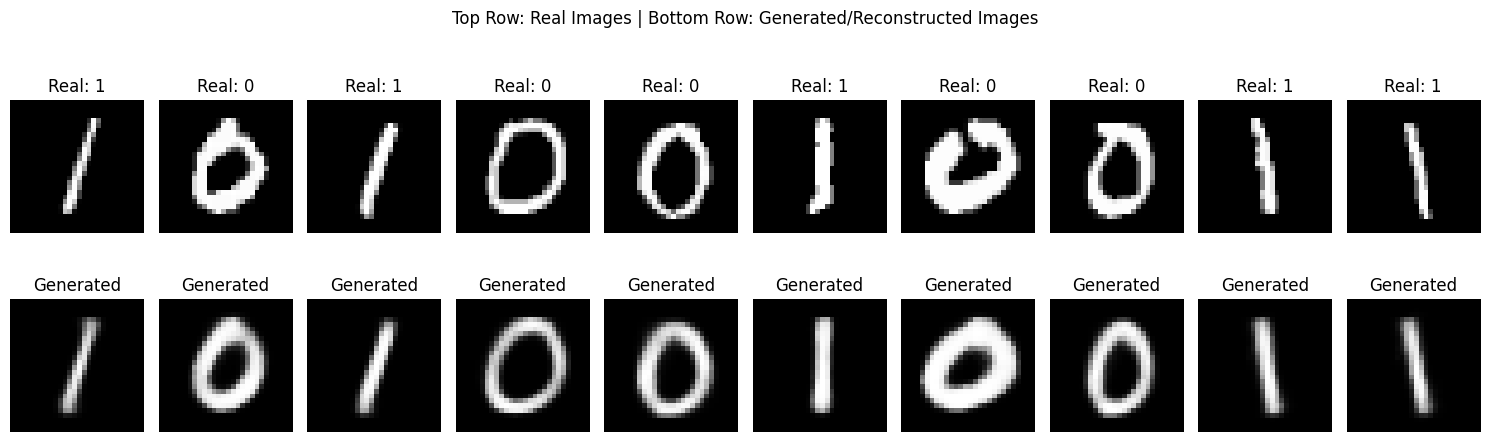

In [11]:
plt.figure(figsize=(15, 5))

for i in range(10):
    # Real image
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"Real: {y_test[i]}")
    plt.axis("off")

    # Generated/Reconstructed image
    plt.subplot(2, 10, i + 11)
    plt.imshow(generated[i], cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.suptitle("Top Row: Real Images | Bottom Row: Generated/Reconstructed Images")
plt.tight_layout()
plt.show()


## 11. Final Comparison

| Feature | Discriminative Model | Generative Model |
|---|---|---|
| Model Used | Logistic Regression | Autoencoder |
| Main Task | Classify images | Learn image patterns and reconstruct images |
| Input | Digit image | Digit image |
| Output | Label: 0 or 1 | Generated/Reconstructed digit image |
| What It Learns | Decision boundary between 0 and 1 | Important patterns/features in the data |
| Evaluation | Classification accuracy | Reconstruction quality and training loss |


## Written Reflection

The discriminative model learned how to distinguish between handwritten digits 0 and 1 by learning a decision boundary between the two classes. It focuses mainly on predicting the correct label for an input image. The generative model learned the important visual patterns present in the digit images and used them to reconstruct similar images. The main difference is that a discriminative model learns **which class an image belongs to**, while a generative model learns **what the data looks like and how it can be recreated**.


## Conclusion

This experiment demonstrates two different approaches to machine learning. Logistic Regression achieved classification by learning the boundary between digits 0 and 1, while the Autoencoder learned a compressed representation of the images and reconstructed them. Therefore, discriminative models are mainly used for prediction and classification, whereas generative models focus on learning the structure or distribution of the input data.
